# DEA WIT Change Detection Module <img align="right" src="./Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with both the `NCI` and `DEA Sandbox` environments
* **Products used:** 
[ga_s2am_ard_3](https://explorer.dea.ga.gov.au/products/ga_s2am_ard_3), 
[ga_s2bm_ard_3](https://explorer.dea.ga.gov.au/products/ga_s2bm_ard_3),
[ga_s2cm_ard_3](https://explorer.dea.ga.gov.au/products/ga_s2cm_ard_3),
[ga_ls5t_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls5t_ard_3),
[ga_ls7e_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls7e_ard_3),
[ga_ls8c_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls8c_ard_3)
* **Special requirements:** An _optional_ description of any special requirements, e.g. If running on the [NCI](https://nci.org.au/), ensure that `module load otps` is run prior to launching this notebook
* **Prerequisites:** An _optional_ list of any notebooks that should be run or content that should be understood prior to launching this notebook


## Background
An *optional* overview of the scientific, economic or environmental management issue or challenge being addressed by Digital Earth Australia. 
For `Beginners_Guide` or `How_to_guides` notebooks, this may include information about why the particular technique or approach is useful or required. 
If you need to cite a scientific paper or link to a website, use a persistent DOI link if possible and link in-text (e.g. [Dhu et al. 2017](https://doi.org/10.1080/20964471.2017.1402490)).


Explain the CCDC 

For gradual cjhanges, code needs to be at least 4 years/ 50 obsetvations so there isnt false postives. 

## Description
A _compulsory_ description of the notebook, including a brief overview of how Digital Earth Australia helps to address the problem set out above.
It can be good to include a run-down of the tools/methods that will be demonstrated in the notebook:

1. Load and Prepare WIT data
2. Define harmonic and trend model
3. Detect abrupt and gradual change
4. Plot change detection
5. Save changes
6. Define polygon geometry for validation
7. Satellite image validation (pre/post change) 

***

## Getting started

Provide any particular instructions that the user might need, e.g. To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis.


In [46]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.linear_model import LinearRegression
from dea_tools.datahandling import load_ard
from datetime import timedelta
from datacube import Datacube
from datacube.utils.geometry import Geometry, CRS 


## 1. Load and prepare WIT data 
An output of the WIT tool is a csv file which we will use to detect change at the site. Add the file name into the line that says "ACTION". The 'date' column will be converted so it is able to be read for time series operations such as plotting and ordered into chronological order. 

In [47]:
csv_path = "ginini_00_10.csv"                    #ACTION: Add CSV output form WIT tool - generates in .../DEA_products/...
df = pd.read_csv(csv_path)

# Convert date and sort
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

## 2. Define harmonic and trend model
We want to flag changes over time, but many changes happen with cyclic and seasonal patterns. This code is designed to tell you what is expected to be seen so you can separate the regular yearly pattern from the underlying trend which then leaves behind residuals that show irregular events or noise. The linear regression estimates how much each component (e.g. seasonal cycles) contributes to overall variation.

In [48]:
def fit_harmonic_trend(dates, values, harmonics=1):
    n = len(values)
    if n < 6:             #ACTION: Change number to determine the minimum amount of observations so there is enough data to fit a meaningful trend.         
        return None, None, None
        
    t = (dates - dates.min()).dt.days.values
    T = 365.25  # 1 year
    X = [np.ones(n), t]

    for k in range(1, harmonics + 1):             #This code captures repeating wave-like patterns.
        X.append(np.sin(2 * np.pi * k * t / T))
        X.append(np.cos(2 * np.pi * k * t / T))

    X = np.vstack(X).T
    model = LinearRegression().fit(X, values)     
    y_pred = model.predict(X)
    residuals = values - y_pred
    rmse = np.sqrt(np.mean(residuals ** 2))
    return y_pred, residuals, rmse


## 3. Detect abrupt and gradual changes
This code detects abrupt and gradual changes in a time series using the above harmonic trend as a baseline. This uses a Continuous Change Detection and Classification (CCDC) algorithm ##(Citation). Abrupt changes are computed using the Median Absolute Deviation (MAD) as a robust measure of variability. For gradual changes, a linear regression is fitted to extract a slope. A threshold based on the standard deviation is set and if the slope exceeds this threshold, it indicates a gradual change.


In [49]:
def detect_ccdc_changes(dates, values, threshold_factor=1.5, consecutive_obs=3):    #ACTION: Change the threshold factor to make it more or less sensitive, default is 1.5.
    y_pred, residuals, rmse = fit_harmonic_trend(dates, values, harmonics=1)
    if y_pred is None:
        return [], [], None

# Abrupt changes
    
    mad = np.median(np.abs(residuals - np.median(residuals)))
    threshold = threshold_factor * mad
    exceed = np.abs(residuals) > threshold

    abrupt_dates = []                            # This code loops and records the date of the first exceedance of the threshold as the start of the abrupt event
    i = 0
    while i < len(exceed):
        if exceed[i]:
            start = i
            count = 1
            while i + 1 < len(exceed) and exceed[i + 1]:
                count += 1
                i += 1
            if count >= consecutive_obs:
                abrupt_dates.append(dates.iloc[start])
        i += 1

# Gradual changes
    
    window = max(5, len(values) // 10)          # This code is sensitive to smaller data sets. Have at least 4 years/50 observations to reduce false positives or adjust code
    slopes = pd.Series(values).rolling(window).apply(lambda x: np.polyfit(range(len(x)), x, 1)[0], raw=True)
    slope_threshold = 0.5 * np.nanstd(values)                                       #ACTION: Change the threshold factor to make it more or less sensitive, default is 0.5.
    gradual_dates = dates[np.abs(slopes) > slope_threshold].iloc[::window].tolist()

    return abrupt_dates, gradual_dates, rmse

## 4. Plot change detection 
This code plots the fractional cover time series as a stacked area chart (same as the WIT tool). It runs the CCDC for each component (pv, npv, bs, wet, water) and calculates the magnitude and direction of each detected change. It also adds descriptions to help interpret the resulting chart. This code also takes all dictionaries in previous code and combines them into a single pandas DataFrame as well as cleaning data, adding ID column and sorting all detected changes into chronological order. It plots and labels vertical lines on the time series graph to show abrupt and gradual change. Finally, it creates an output csv file in the DEA_products folder.

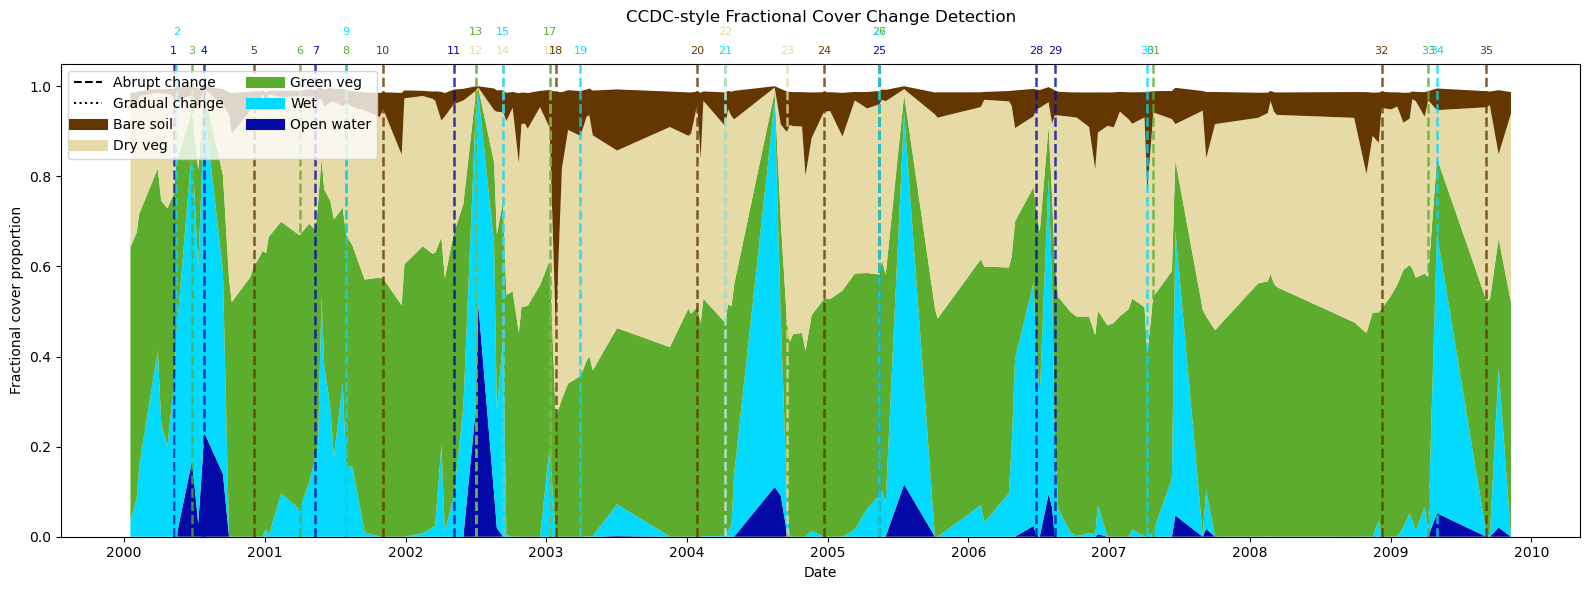

In [50]:
change_summary = []
components = ["bs", "npv", "pv", "wet", "water"]

color_map = {
    "water": "#030aa7",
    "wet": "#04d9ff",
    "bs": "#653700",
    "npv": "#e6daa6",
    "pv": "#5cac2d"
}
label_map = {
    "water": "Open water",
    "wet": "Wet",
    "bs": "Bare soil",
    "npv": "Dry veg",
    "pv": "Green veg"
}

fig, ax = plt.subplots(figsize=(16, 6))
ax.stackplot(
    df["date"],
    *[df[c] for c in components[::-1]],
    labels=[label_map[c] for c in components[::-1]],
    colors=[color_map[c] for c in components[::-1]]
)

for c in components:
    abrupt_dates, gradual_dates, rmse = detect_ccdc_changes(df["date"], df[c])
    for change_type, dates in [("Abrupt", abrupt_dates), ("Gradual", gradual_dates)]:
        for d in dates:
            idx = df.index[df["date"] == d][0]
            pre_window = 3 if change_type == "Abrupt" else 5
            post_window = 3 if change_type == "Abrupt" else 5
            pre = df[c].iloc[max(0, idx - pre_window):idx].mean()
            post = df[c].iloc[idx:min(len(df), idx + post_window)].mean()
            pct_change = ((post - pre) / pre) * 100 if pre != 0 else np.nan
            if 1 < idx < len(df) - 1:
                diff = df[c].iloc[idx + 1] - df[c].iloc[idx - 1]
            else:
                diff = np.nan
            if np.isnan(diff):
                desc = "Insufficient data to interpret change."
            else:
                if c == "pv":
                    desc = "Expansion of green vegetation" if diff > 0 else "Reduction of photosynthetic vegetation"
                elif c == "npv":
                    desc = "Increase in dry/non-photosynthetic vegetation" if diff > 0 else "Decline in dry vegetation"
                elif c == "bs":
                    desc = "Increase in exposed bare ground" if diff > 0 else "Decline in bare soil (possible vegetation regrowth)"
                elif c == "wet":
                    desc = "Expansion of moist/wet surface areas" if diff > 0 else "Drying trend in wet areas"
                elif c == "water":
                    desc = "Expansion of open water areas" if diff > 0 else "Contraction of open water areas"
                else:
                    desc = "Unclassified change"
            change_summary.append({
                "Component": c,
                "Date": d,
                "Type": change_type,
                "Change_%": round(pct_change, 2),
                "Description": desc
            })

change_df = pd.DataFrame(change_summary)
if not change_df.empty:
    change_df["Date"] = pd.to_datetime(change_df["Date"], errors="coerce")
    change_df = change_df.sort_values("Date").reset_index(drop=True)
    change_df["ID"] = np.arange(1, len(change_df) + 1)
else:
    change_df = pd.DataFrame([{
        "ID": np.nan, "Component": np.nan, "Date": np.nan,
        "Type": np.nan, "Change_%": np.nan, "Description": np.nan
    }])

y_offset_map = {}
for _, row in change_df.iterrows():
    if pd.isna(row["Date"]):
        continue
    date_key = pd.to_datetime(row["Date"]).strftime("%Y-%m-%d")
    nearby = [d for d in y_offset_map if abs((pd.to_datetime(d) - pd.to_datetime(date_key)).days) < 10]
    offset = len(nearby) * 0.04
    y_offset_map[date_key] = offset
    color = color_map.get(row["Component"], "black")
    linestyle = "--" if row["Type"] == "Abrupt" else ":"
    ax.axvline(row["Date"], color=color, linestyle=linestyle, linewidth=1.8, alpha=0.8)
    ax.text(row["Date"], 1.02 + y_offset_map[date_key], str(int(row["ID"])), color=color,
            fontsize=8, ha="center", transform=ax.get_xaxis_transform())

from matplotlib.lines import Line2D
legend_lines = [
    Line2D([0], [0], color="black", linestyle="--", label="Abrupt change"),
    Line2D([0], [0], color="black", linestyle=":", label="Gradual change")
]

ax.legend(
    handles=legend_lines + [
        Line2D([0], [0], color=color_map[c], linewidth=8, label=label_map[c])
        for c in components
    ],
    loc="upper left", ncol=2
)

ax.set_title("CCDC-style Fractional Cover Change Detection", pad=30)
ax.set_ylabel("Fractional cover proportion")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

In [51]:
Fire overlay EDITING

SyntaxError: invalid syntax (97129056.py, line 1)

In [ ]:


# # 🔥 Add Bushfire Overlap Detection and Plotting


# # Load bushfire polygons
# bushfire_shp = "path_to_your_bushfire_layer.shp"   #Bushfirelayer
# bushfire_gdf = gpd.read_file(bushfire_shp)

# # Load your area extent polygon (study site)
# extent_shp = "path_to_your_area_extent_polygon.shp"
# extent_gdf = gpd.read_file(extent_shp)

# # Ensure same CRS
# if bushfire_gdf.crs != extent_gdf.crs:
#     bushfire_gdf = bushfire_gdf.to_crs(extent_gdf.crs)

# # Clip to your area extent
# fire_clipped = gpd.clip(bushfire_gdf, extent_gdf)

# # Keep only relevant columns (optional)
# # Assuming there’s an ignition date column called "IGNITION_DATE" or similar
# fire_clipped = fire_clipped[["IGNITION_DATE", "geometry"]].copy()

# # Convert ignition date to datetime
# fire_clipped["IGNITION_DATE"] = pd.to_datetime(fire_clipped["IGNITION_DATE"], errors="coerce")
# fire_clipped = fire_clipped.dropna(subset=["IGNITION_DATE"])

# # Extract unique ignition dates (in case multiple polygons share the same date)
# fire_dates = sorted(fire_clipped["IGNITION_DATE"].unique())

# # Add fire dates into your change_df for reference
# if not fire_dates:
#     print("No fires overlapping the study area.")
# else:
#     for fire_date in fire_dates:
#         change_df.loc[len(change_df)] = {|
#             "ID": np.nan,
#             "Component": "fire",
#             "Date": fire_date,
#             "Type": "Fire",
#             "Change_%": np.nan,
#             "Description": "Bushfire overlap detected on site"
#         }

# # Plot fire events as vertical lines with 🔥 emoji
# for fire_date in fire_dates:
#     ax.axvline(fire_date, color="red", linestyle="-", linewidth=2.2, alpha=0.8)

#     # Slight vertical placement offset to prevent overlap with other text
#     nearby = [d for d in y_offset_map if abs((pd.to_datetime(d) - pd.to_datetime(fire_date)).days) < 10]
#     offset = len(nearby) * 0.05
#     y_offset_map[str(fire_date.date())] = offset

#     ax.text(
#         fire_date, 
#         1.04 + offset,  # Adjust vertical placement if needed
#         "🔥", 
#         fontsize=12, 
#         ha="center", 
#         transform=ax.get_xaxis_transform()
#     )


## 7. Save changes
This code creates an output csv file in the DEA_products folder.

In [52]:
output_csv = csv_path.replace(".csv", "_CCDC_ChangeSummary.csv")
change_df.to_csv(output_csv, index=False, na_rep="NaN")
print(f"✅ Change summary saved to: {output_csv}")
print(change_df)


✅ Change summary saved to: ginini_00_10_CCDC_ChangeSummary.csv
   Component                       Date    Type   Change_%  \
0      water 2000-05-08 23:42:49.967418  Abrupt        NaN   
1        wet 2000-05-15 23:48:35.324805  Abrupt     118.20   
2         pv 2000-06-25 23:42:24.846675  Abrupt     -75.06   
3      water 2000-07-27 23:41:53.481601  Abrupt      87.65   
4         bs 2000-12-02 23:41:02.461123  Abrupt     -62.57   
5         pv 2001-03-31 23:46:36.651641  Abrupt     -10.24   
6      water 2001-05-11 23:40:38.429070  Abrupt        NaN   
7         pv 2001-07-30 23:39:51.469601  Abrupt      13.62   
8        wet 2001-07-30 23:39:51.469601  Abrupt     -59.90   
9         bs 2001-11-03 23:39:03.888393  Abrupt      49.17   
10     water 2002-05-05 23:45:19.204468  Abrupt  104321.41   
11       npv 2002-07-01 23:39:07.892111  Abrupt     -85.79   
12        pv 2002-07-01 23:39:07.892111  Abrupt     -85.22   
13       npv 2002-09-10 23:44:24.502080  Abrupt     154.06   
14     

## 8. Define polygon geometry for validation 
This code utilises the polygon that was an input into the WIT tool. Use the same polygon to verify the change detection points. 

In [53]:
polygon_path = "ginini_flats.shp"   #ACTION: change this if your polygon file has another name
poly = gpd.read_file(polygon_path)

# Ensure CRS is defined (use the same projection as WIT)
if poly.crs is None:
    poly = poly.set_crs("EPSG:3577")  # or EPSG:4326 if your polygon is in lat/long

# Convert to datacube geometry
gpgon = Geometry(poly.geometry[0], CRS(str(poly.crs)))

## 9. Satellite image validation (pre/post change) 
The time-series needs to be validated. This code chunk lets you select a change detection line based on the ID and pulls satellite imagery from before and after the change was detected. Because of the resolution of the imagery, smaller sites are more difficult to analyse. Each parameter will result in pre and post imagery for every component, so there will be 10 images per change detection. 

In [56]:
# Parameters
change_id_to_validate = 3   # ACTION: Change this number to select which change to validate based on the ID in both the graph and table
time_window_days = 15       # ACTION: How many days before/after to search for images

# Locate the change event
selected_change = change_df.loc[change_df["ID"] == change_id_to_validate]

if selected_change.empty:
    raise ValueError(f"No change found with ID {change_id_to_validate}")

change_date = selected_change["Date"].values[0]
change_date = pd.to_datetime(change_date)

# Define time range (before and after change)
time_before = (change_date - timedelta(days=time_window_days)).strftime("%Y-%m-%d")
time_after  = (change_date + timedelta(days=time_window_days)).strftime("%Y-%m-%d")

# Load satellite data around the change date
bands = [f"nbart_{band}" for band in ("blue", "green", "red", "nir", "swir_1", "swir_2")]

dc = Datacube(app="change_validation")

ds = load_ard(
    dc,
    products=["ga_ls8c_ard_3", "ga_ls7e_ard_3", "ga_ls5t_ard_3"],
    ls7_slc_off=False,
    measurements=bands,
    geopolygon=gpgon,
    output_crs="EPSG:3577",
    resolution=(-30, 30),
    resampling={"fmask": "nearest", "*": "bilinear"},
    time=(time_before, time_after),
    group_by="solar_day",
    dask_chunks={"time": 1, "x": 2048, "y": 2048},
)

# Load into memory
ds.load()

# Define output folder
out_folder = "validation_images"
os.makedirs(out_folder, exist_ok=True)

# Identify nearest pre- and post-change images
time_values = ds.time.values
closest_pre_idx = (np.abs(time_values - np.datetime64(change_date - timedelta(days=1)))).argmin()
closest_post_idx = (np.abs(time_values - np.datetime64(change_date + timedelta(days=1)))).argmin()

# Select datasets
pre_ds = ds.isel(time=closest_pre_idx)
post_ds = ds.isel(time=closest_post_idx)

# Save images
pre_path = os.path.join(out_folder, f"change_{change_id_to_validate}_before.tif")
post_path = os.path.join(out_folder, f"change_{change_id_to_validate}_after.tif")

pre_ds.to_netcdf(pre_path)
post_ds.to_netcdf(post_path)

print(f"✅ Saved validation images for Change ID {change_id_to_validate}")
print(f"Before: {pre_path}")
print(f"After:  {post_path}")

Finding datasets
    ga_ls8c_ard_3
    ga_ls7e_ard_3 (ignoring SLC-off observations)
    ga_ls5t_ard_3
Applying fmask pixel quality/cloud mask
Returning 3 time steps as a dask array


ValueError: failed to prevent overwriting existing key units in attrs on variable 'time'. This is probably an encoding field used by xarray to describe how a variable is serialized. To proceed, remove this key from the variable's attributes manually.

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** September 2021

**Compatible datacube version:** 

In [ ]:
print(datacube.__version__)

In [ ]:
## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->

In [ ]:
**Tags**: :index:`template`, :index:`sandbox compatible`, 